# Common Task 1: Autoencoder for Quark/Gluon Jet Events

Training a convolutional autoencoder to learn compressed representations of jet events from the quark/gluon dataset. The dataset has 139,306 events with 3 channels (ECAL, HCAL, Tracks) at 125×125 resolution.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Exploration

Keys: ['X_jets', 'm0', 'pt', 'y']
  X_jets: shape=(139306, 125, 125, 3), dtype=float32
  m0: shape=(139306,), dtype=float32
  pt: shape=(139306,), dtype=float32
  y: shape=(139306,), dtype=float32

Label distribution: (array([0., 1.], dtype=float32), array([69653, 69653]))

Sample shape: (5000, 125, 125, 3)
Value range: [0.000000, 9.868629], mean: 0.000053
ECAL — range: [0.0000, 9.8686], mean: 0.000078, nonzero: 0.0049
HCAL — range: [0.0000, 1.6508], mean: 0.000049, nonzero: 0.0153
Tracks — range: [0.0000, 0.1573], mean: 0.000031, nonzero: 0.0267


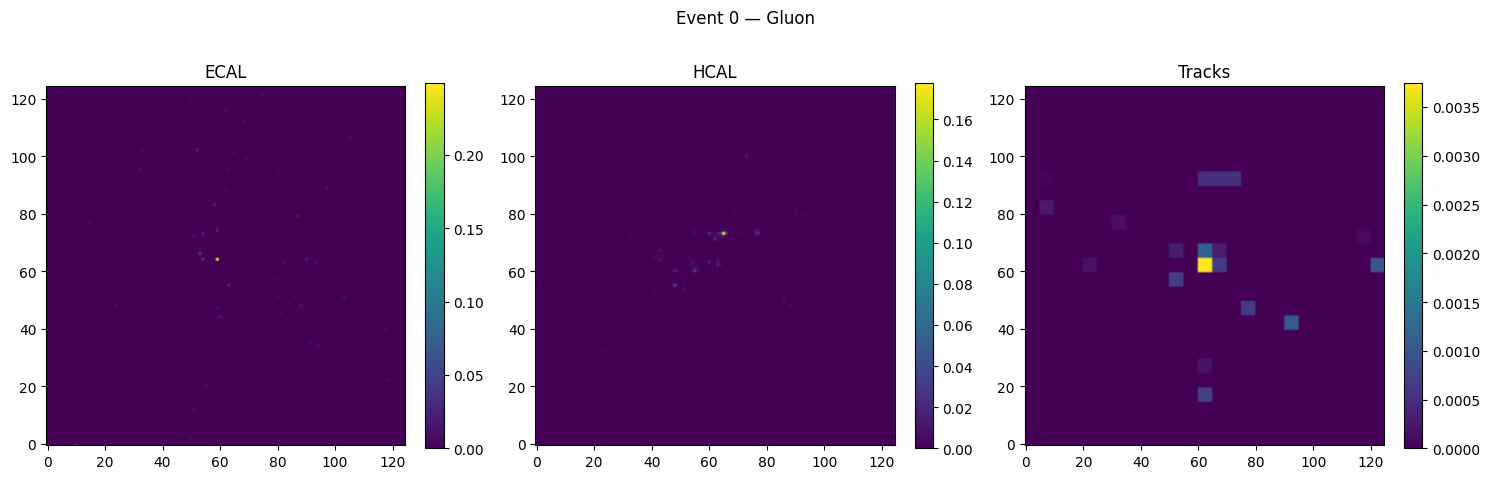

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filepath = '/content/drive/MyDrive/quark-gluon_data-set_n139306.hdf5'

with h5py.File(filepath, 'r') as f:
    print("Keys:", list(f.keys()))
    for key in f.keys():
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")

    y = f['y'][:]
    print(f"\nLabel distribution: {np.unique(y, return_counts=True)}")

    X_sample = f['X_jets'][:5000]
    print(f"\nSample shape: {X_sample.shape}")
    print(f"Value range: [{X_sample.min():.6f}, {X_sample.max():.6f}], mean: {X_sample.mean():.6f}")

    channel_names = ['ECAL', 'HCAL', 'Tracks']
    for i, name in enumerate(channel_names):
        ch = X_sample[:, :, :, i]
        print(f"{name} — range: [{ch.min():.4f}, {ch.max():.4f}], "
              f"mean: {ch.mean():.6f}, nonzero: {(ch > 0).mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
idx = 0
for i, ax in enumerate(axes):
    im = ax.imshow(X_sample[idx, :, :, i], cmap='viridis', origin='lower')
    ax.set_title(channel_names[i])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'Event {idx} — {"Quark" if y[idx]==1 else "Gluon"}')
plt.tight_layout()
plt.show()

The images are extremely sparse — ECAL has ~0.5%, HCAL ~1.5%, and Tracks ~2.7% nonzero pixels. The energy values are also very small (max ~10, mean ~5e-5), so standard MSE would be dominated by the zero background. To handle this:

1. **Log transform** (`log1p(x * 1000)`) to compress the dynamic range and spread out small values
2. **Per-channel normalization** to [0, 1]
3. **Weighted MSE loss** that penalizes errors on nonzero pixels 50x more heavily

The autoencoder is fully convolutional (no FC bottleneck) to preserve spatial information through the latent space.

## Preprocessing and Model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import time
import gc

N_EVENTS = 10000  # subset due to Colab RAM; pipeline scales to full 139K
BATCH_SIZE = 32
EPOCHS = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

with h5py.File(filepath, 'r') as f:
    X = f['X_jets'][:N_EVENTS].astype('float32')
    y = f['y'][:N_EVENTS]

X = np.log1p(X * 1000)
ch_max = []
for i in range(3):
    m = X[:, :, :, i].max()
    ch_max.append(m)
    if m > 0:
        X[:, :, :, i] /= m
print(f"Per-channel max (post log1p): {[f'{m:.3f}' for m in ch_max]}")

X = np.transpose(X, (0, 3, 1, 2)).astype(np.float16)
gc.collect()

split = int(0.85 * N_EVENTS)
X_train = torch.tensor(X[:split]).float()
X_val = torch.tensor(X[split:]).float()
y_val = y[split:]
del X; gc.collect()
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

train_ds = DataLoader(TensorDataset(X_train, X_train), batch_size=BATCH_SIZE, shuffle=True)
val_ds = DataLoader(TensorDataset(X_val, X_val), batch_size=BATCH_SIZE, shuffle=False)

Device: cuda
Per-channel max (post log1p): ['9.219', '9.142', '5.888']
Train: torch.Size([8500, 3, 125, 125]), Val: torch.Size([1500, 3, 125, 125])


In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),     # 125 -> 63
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),    # 63 -> 32
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),   # 32 -> 16
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 32, 1),                         # 1x1 channel compression
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 128, 1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 16 -> 32
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),   # 32 -> 64
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),   # 64 -> 128
            nn.BatchNorm2d(16), nn.LeakyReLU(0.2),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out[:, :, 2:127, 2:127]  # crop 128 -> 125


class WeightedMSE(nn.Module):
    def __init__(self, nonzero_weight=50.0):
        super().__init__()
        self.w = nonzero_weight

    def forward(self, recon, target):
        weight = torch.ones_like(target)
        weight[target > 0] = self.w
        return (weight * (recon - target) ** 2).mean()


model = ConvAutoencoder().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 199,907


## Training

Epoch 01/50 — train: 0.022555, val: 0.003788, lr: 0.001000, time: 9.3s
Epoch 05/50 — train: 0.001531, val: 0.001403, lr: 0.001000, time: 9.6s
Epoch 10/50 — train: 0.001049, val: 0.000969, lr: 0.001000, time: 8.0s
Epoch 15/50 — train: 0.000875, val: 0.000818, lr: 0.001000, time: 8.4s
Epoch 20/50 — train: 0.000765, val: 0.000770, lr: 0.001000, time: 8.4s
Epoch 25/50 — train: 0.000697, val: 0.000666, lr: 0.001000, time: 8.4s
Epoch 30/50 — train: 0.000640, val: 0.000620, lr: 0.001000, time: 8.4s
Epoch 35/50 — train: 0.000601, val: 0.000685, lr: 0.001000, time: 8.7s
Epoch 40/50 — train: 0.000572, val: 0.000564, lr: 0.001000, time: 8.5s
Epoch 45/50 — train: 0.000539, val: 0.000524, lr: 0.001000, time: 8.5s
Epoch 50/50 — train: 0.000535, val: 0.000530, lr: 0.001000, time: 8.5s


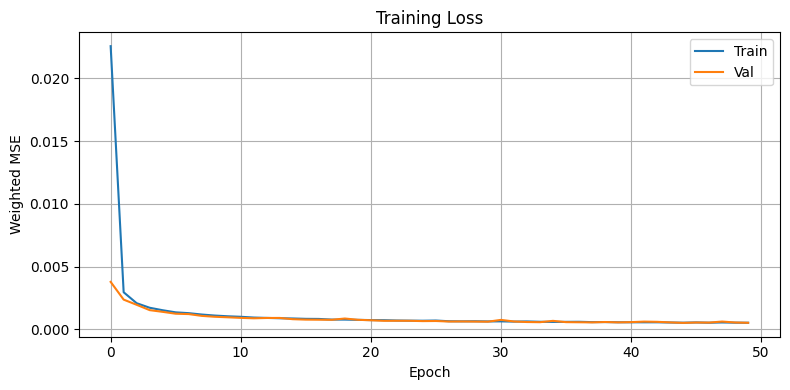

In [ ]:
criterion = WeightedMSE(nonzero_weight=50.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)

train_losses, val_losses = [], []
for epoch in range(EPOCHS):
    t0 = time.time()

    model.train()
    eloss = 0
    for xb, _ in train_ds:
        xb = xb.to(device)
        loss = criterion(model(xb), xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        eloss += loss.item() * xb.size(0)
    tl = eloss / len(X_train)

    model.eval()
    evloss = 0
    with torch.no_grad():
        for xb, _ in val_ds:
            xb = xb.to(device)
            evloss += criterion(model(xb), xb).item() * xb.size(0)
    vl = evloss / len(X_val)

    train_losses.append(tl)
    val_losses.append(vl)
    scheduler.step(vl)
    dt = time.time() - t0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} — train: {tl:.6f}, val: {vl:.6f}, "
              f"lr: {optimizer.param_groups[0]['lr']:.6f}, time: {dt:.1f}s")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('Weighted MSE')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Reconstruction Results

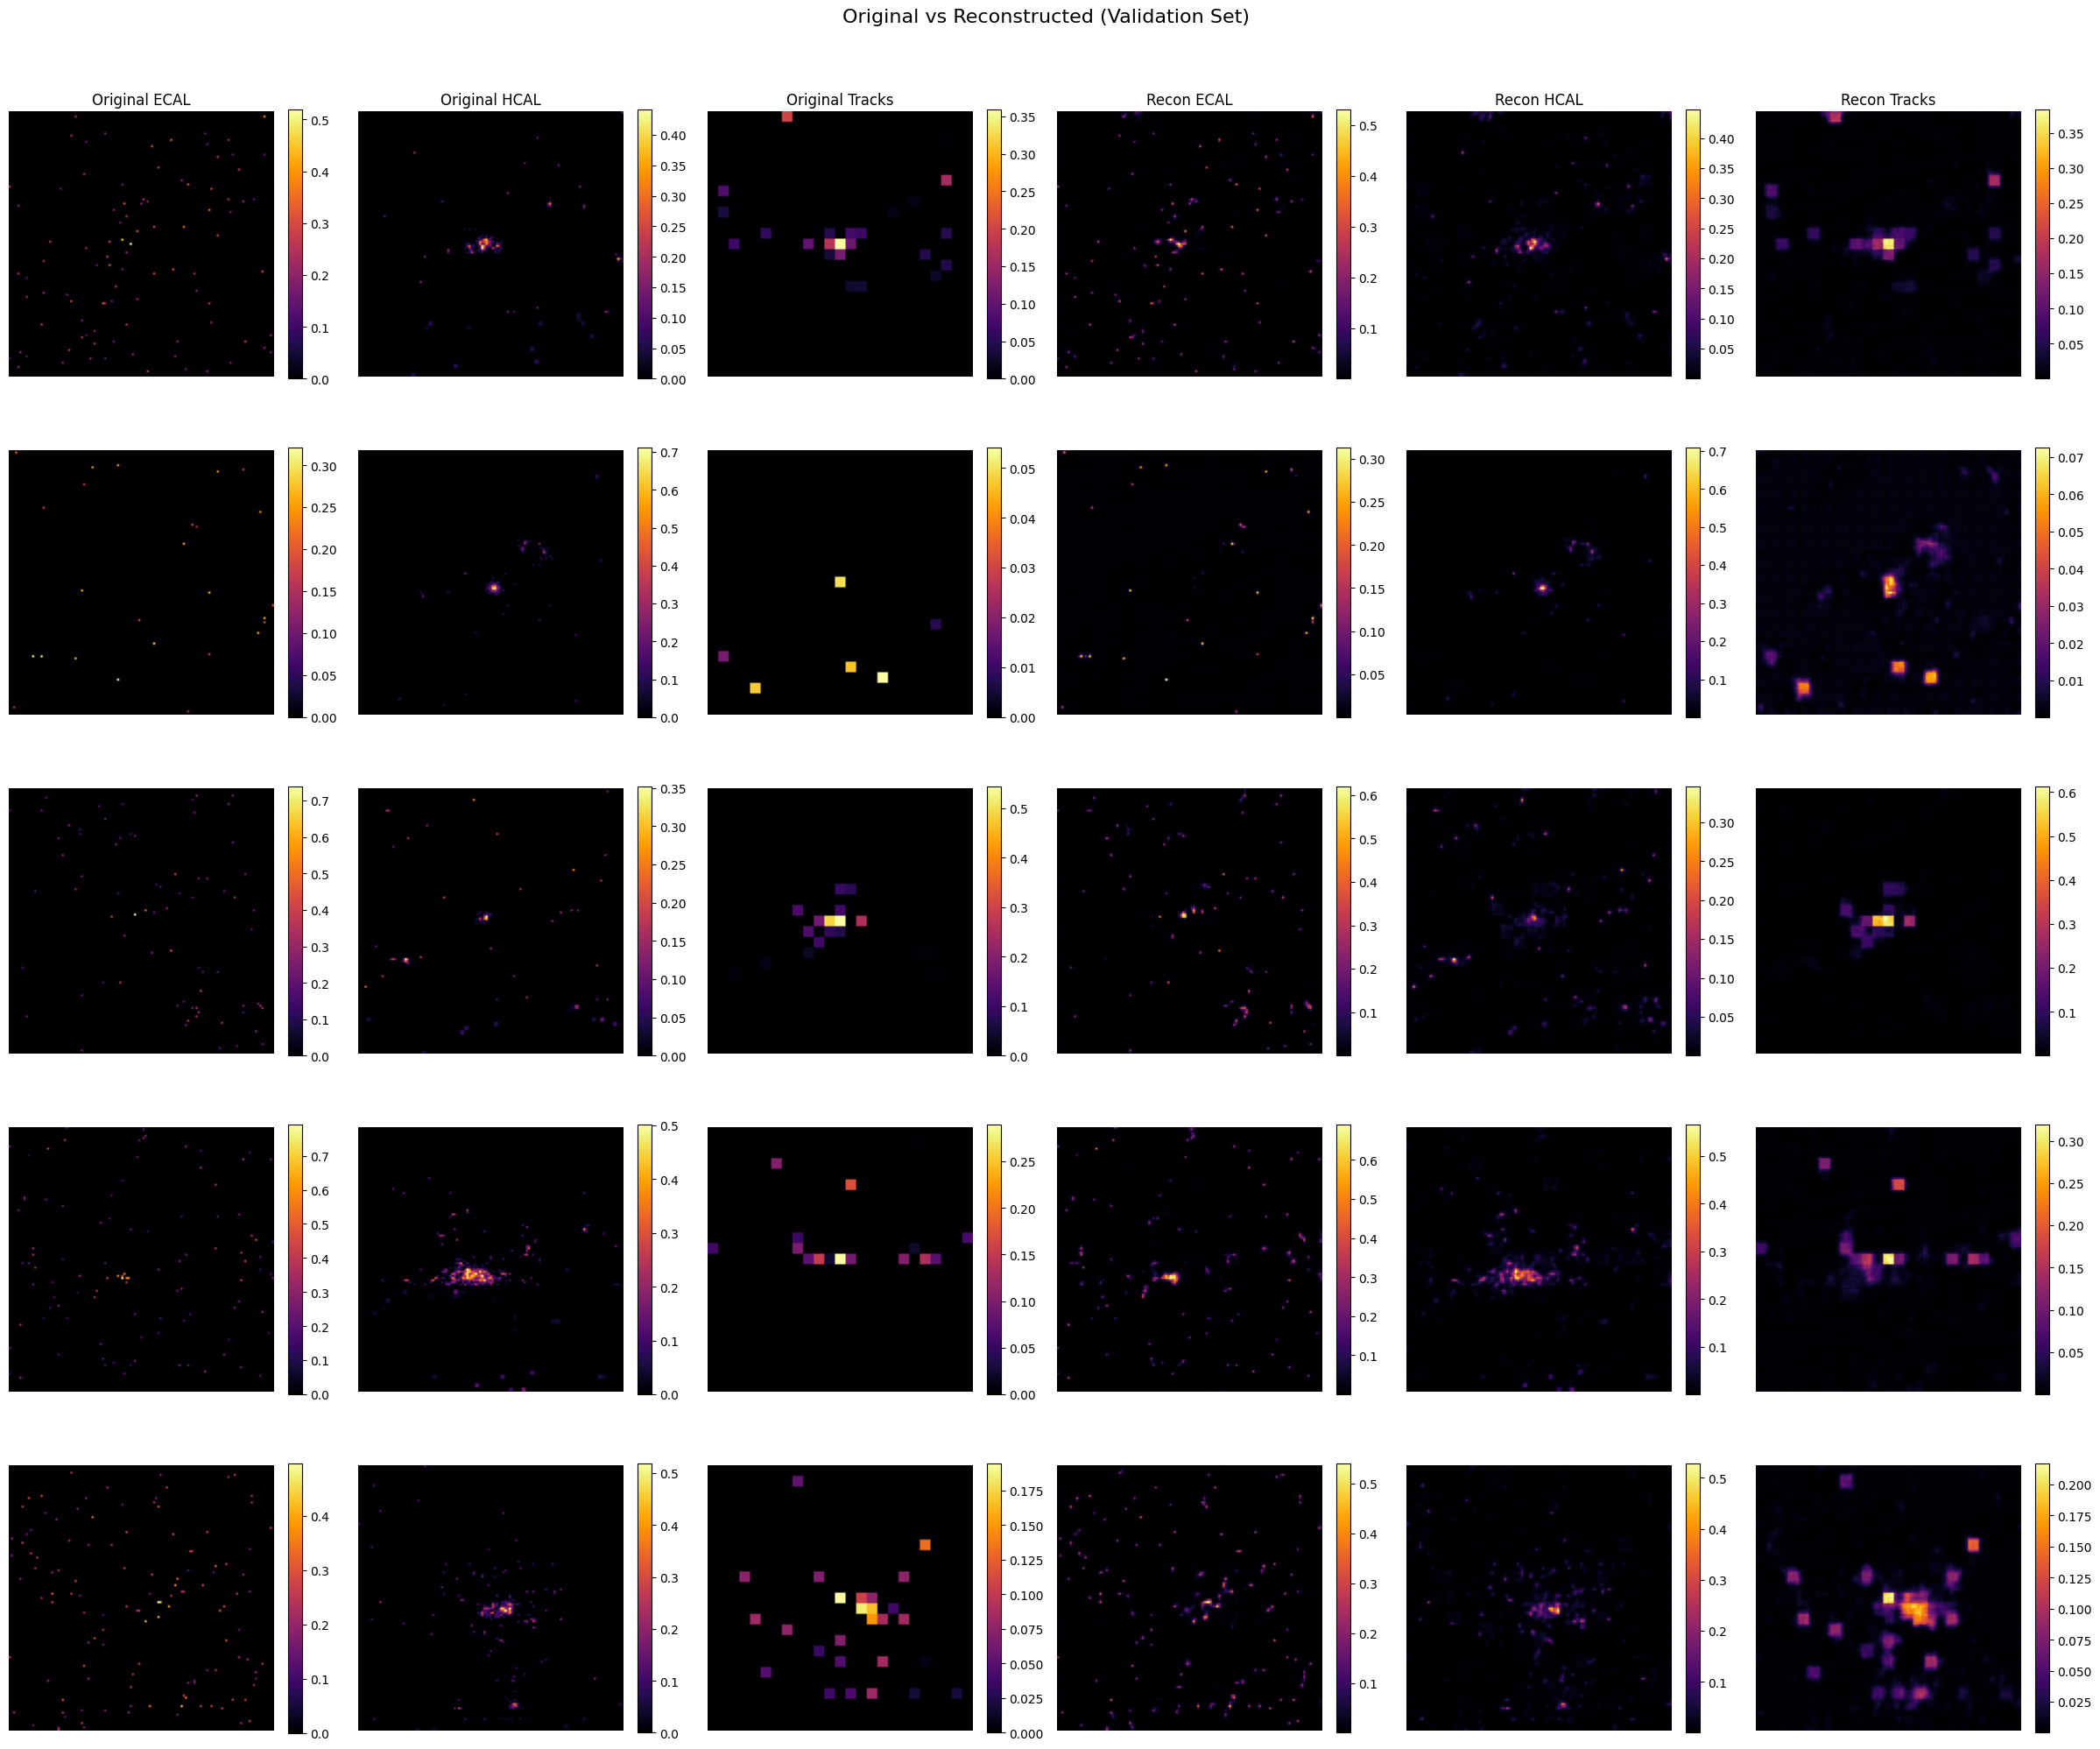

In [ ]:
channel_names = ['ECAL', 'HCAL', 'Tracks']
n_examples = 5

model.eval()
with torch.no_grad():
    sample = X_val[:n_examples].to(device)
    recon = model(sample).cpu().numpy()
    original = sample.cpu().numpy()

fig, axes = plt.subplots(n_examples, 6, figsize=(24, 4 * n_examples))
for i in range(n_examples):
    for ch in range(3):
        ax = axes[i, ch]
        im = ax.imshow(original[i, ch], cmap='inferno', origin='lower')
        if i == 0:
            ax.set_title(f'Original {channel_names[ch]}', fontsize=12)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

        ax = axes[i, ch + 3]
        im = ax.imshow(recon[i, ch], cmap='inferno', origin='lower')
        if i == 0:
            ax.set_title(f'Recon {channel_names[ch]}', fontsize=12)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Original vs Reconstructed (Validation Set)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Residual Analysis

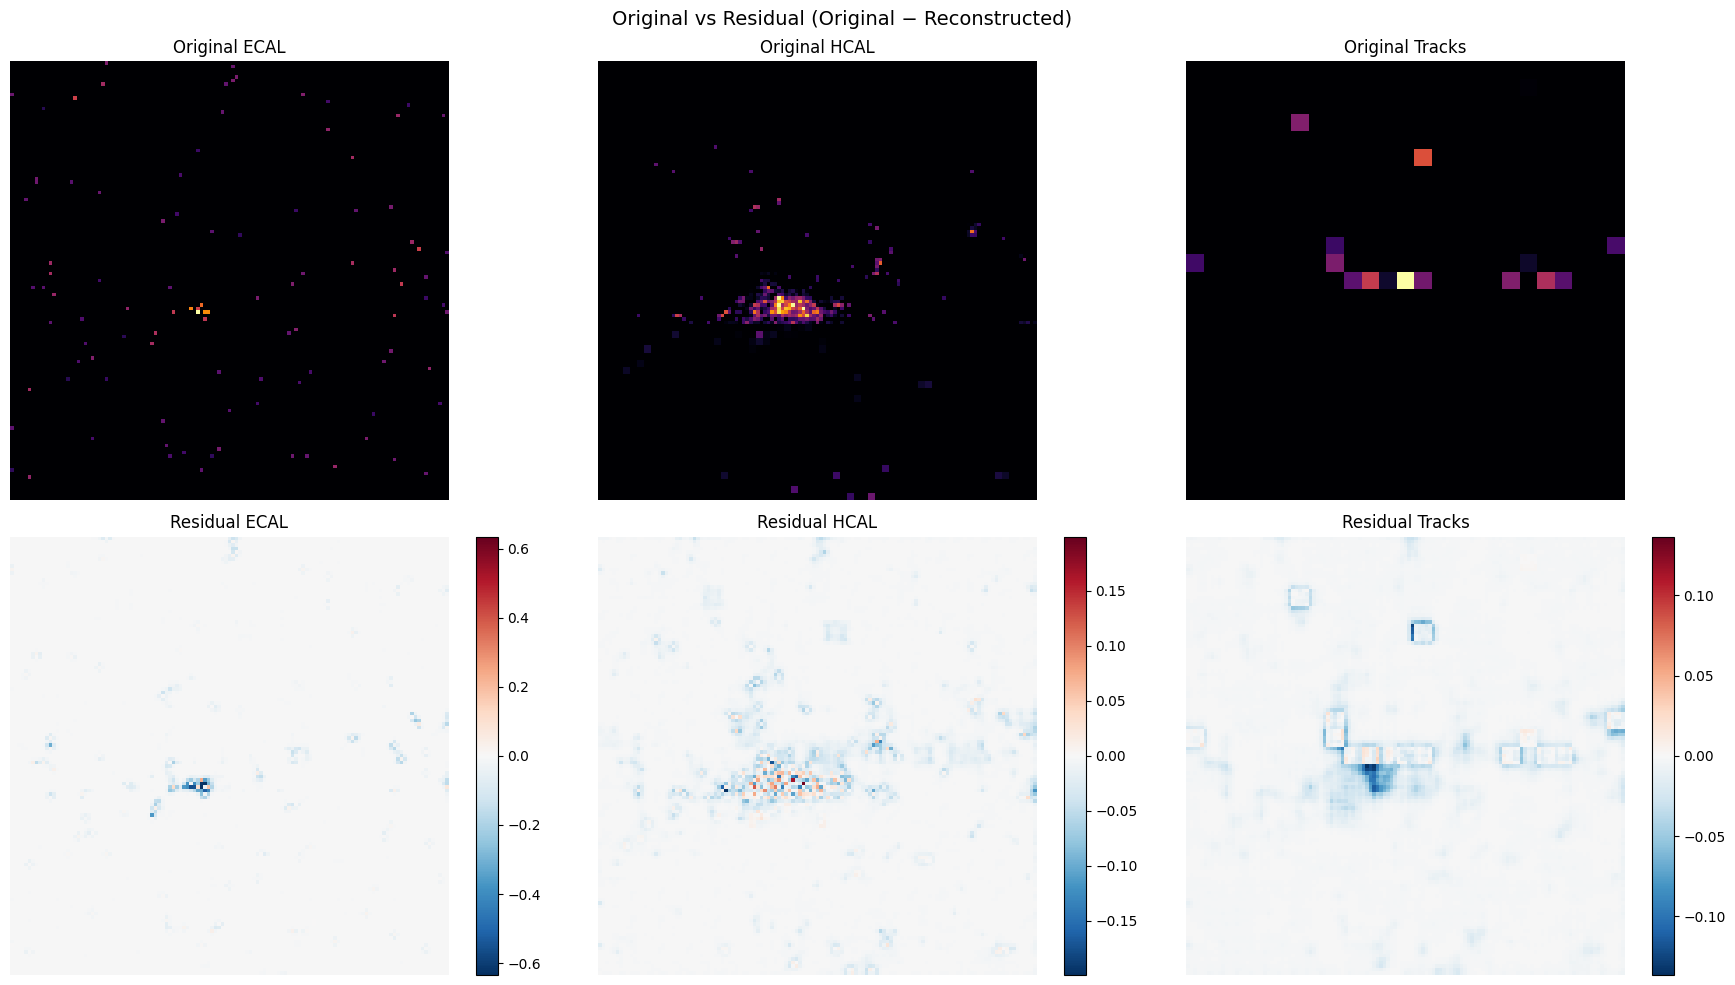

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
idx = 3

model.eval()
with torch.no_grad():
    sample = X_val[idx:idx+1].to(device)
    recon_img = model(sample).cpu().numpy()[0]
    orig_img = sample.cpu().numpy()[0]

for ch in range(3):
    axes[0, ch].imshow(orig_img[ch], cmap='inferno', origin='lower')
    axes[0, ch].set_title(f'Original {channel_names[ch]}')
    axes[0, ch].axis('off')

    residual = orig_img[ch] - recon_img[ch]
    im = axes[1, ch].imshow(residual, cmap='RdBu_r', origin='lower',
                             vmin=-np.abs(residual).max(), vmax=np.abs(residual).max())
    axes[1, ch].set_title(f'Residual {channel_names[ch]}')
    axes[1, ch].axis('off')
    plt.colorbar(im, ax=axes[1, ch], fraction=0.046)

plt.suptitle('Original vs Residual (Original − Reconstructed)', fontsize=14)
plt.tight_layout()
plt.show()

## Latent Space Visualization

Latent shape: (1500, 8192)


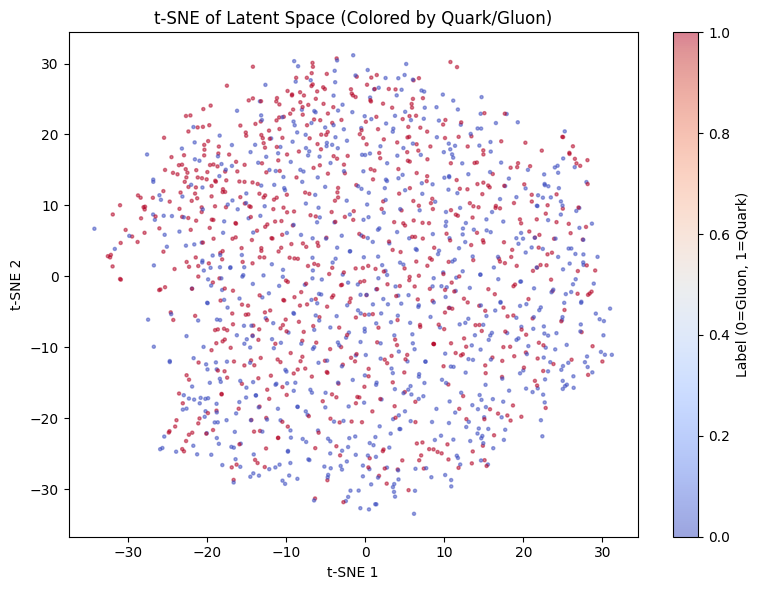

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

model.eval()
latents = []
with torch.no_grad():
    for xb, _ in val_ds:
        xb = xb.to(device)
        z = model.encoder(xb)
        latents.append(z.flatten(1).cpu().numpy())
latents = np.concatenate(latents)
print(f"Latent shape: {latents.shape}")

pca = PCA(n_components=50)
latents_pca = pca.fit_transform(latents)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latents_2d = tsne.fit_transform(latents_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c=y_val, cmap='coolwarm', alpha=0.5, s=5)
plt.colorbar(scatter, label='Label (0=Gluon, 1=Quark)')
plt.title('t-SNE of Latent Space (Colored by Quark/Gluon)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## Summary

The fully convolutional autoencoder successfully learns to reconstruct the sparse jet images. The log transform and weighted MSE loss were both necessary — without them, the model collapses to reconstructing a generic central blob since 97% of pixels are zero.

The residual plots confirm that reconstruction errors are concentrated at the energy deposit locations rather than spread randomly, which is expected behavior for a compressed representation.

The t-SNE visualization of the latent space shows partial clustering by jet type (quark vs gluon), despite the autoencoder being trained without labels. This suggests the learned representation captures physically meaningful features of the jet substructure.

**Note:** Training was performed on 10K events due to Colab memory constraints. The architecture and pipeline scale directly to the full 139K dataset with sufficient compute.